# Minimal Linear Coordination System

This notebook reproduces the minimal linear coordination example presented in the manuscript.

The goal is to illustrate the closed-loop dynamics described in the paper using a simple computational simulation.

Two agents adapt their actions in response to incentive signals generated by a persistent but dissipative environment.

The system is defined by the following equations:

### Agent updates

$$
x_{1,t+1}=
x_{1,t}
+
\eta G_{1,t},
\qquad
x_{2,t+1}=
x_{2,t}
+
\eta G_{2,t}
$$

### Environmental persistence

$$
S_{t+1}=
(1 - \gamma) S_t
+
\beta (x_{1,t} - x_{2,t})
$$


### Incentive field

$$
G_{1,t} = -2\beta S_t,
\qquad
G_{2,t} = +2\beta S_t
$$

The environment accumulates disagreement and feeds it back through incentives.

Stability requires the dissipative condition

$$
4 \eta \beta^2 < \gamma
$$

Under this condition, disagreement decays and the agents converge toward coordination.

## Model Parameters

We simulate the coordination dynamics using parameters satisfying the stability condition:

$$
4 \eta \beta^2 < \gamma
$$

The values below ensure dissipative feedback dynamics.

## Expected Behavior

Because the stability condition

$$
4 \eta \beta^2 < \gamma
$$

is satisfied, the coordination equilibrium is locally asymptotically stable.  
The disagreement between agents decays over time, and the environmental stress variable converges toward zero.

The trajectories exhibit damped oscillations that converge toward the coordination equilibrium.

## Reproducibility

The simulation is deterministic and fully reproducible.  
Random seeds are fixed for both NumPy and PyTorch to ensure identical results across runs.

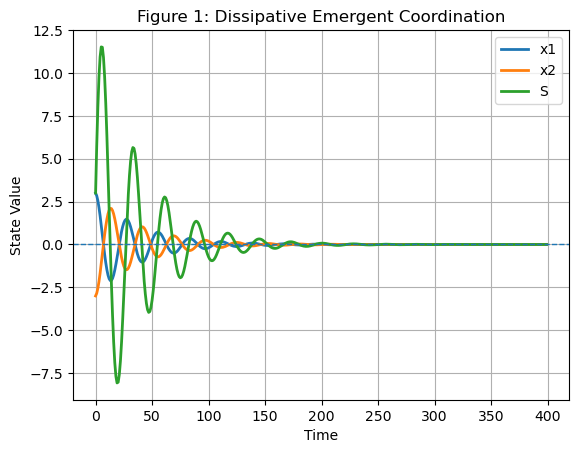

Final disagreement: -9.277854251997237e-05

The final disagreement is approximately zero (up to numerical precision),
confirming convergence of the coordination dynamics.


In [1]:
# Import Required Libraries
import numpy as np
import torch
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)
torch.set_default_dtype(torch.float64)


# Simulation horizon
T = 400

# Model parameters
beta = 0.5
eta = 0.05
gamma = 0.1   # Must satisfy 4*eta*beta^2 < gamma

# Initial conditions
x1 = torch.tensor(3.0)
x2 = torch.tensor(-3.0)
S = torch.tensor(0.0)

# Storage
x1_hist = []
x2_hist = []
S_hist = []

# Closed-loop coordination dynamics
for t in range(T):

    # Store previous actions for environmental update
    x1_old = x1
    x2_old = x2

    # Incentive field
    G1 = -2 * beta * S
    G2 = +2 * beta * S

    # Agent adaptation
    x1 = x1 + eta * G1
    x2 = x2 + eta * G2

    # Environmental persistence
    S = (1 - gamma) * S + beta * (x1_old - x2_old)

    # Record trajectories
    x1_hist.append(x1.item())
    x2_hist.append(x2.item())
    S_hist.append(S.item())

# ------------------------------------------------------------
# Plot 1: Dissipative Emergent Coordination
# ------------------------------------------------------------

plt.figure()

plt.plot(x1_hist, label="x1", linewidth=2)
plt.plot(x2_hist, label="x2", linewidth=2)
plt.plot(S_hist, label="S", linewidth=2)

plt.title("Figure 1: Dissipative Emergent Coordination")
plt.xlabel("Time")
plt.ylabel("State Value")

plt.axhline(0, linestyle="--", linewidth=1)

plt.legend()
plt.grid(True)

plt.show()

# Report final disagreement between agents
print("Final disagreement:", x1.item() - x2.item())
print("\nThe final disagreement is approximately zero (up to numerical precision),")
print("confirming convergence of the coordination dynamics.")

## Interpretation

The two agents initially choose strongly different actions.

This disagreement generates environmental stress through the persistence equation

$$
S_{t+1}=
(1 - \gamma) S_t
+
\beta (x_{1,t} - x_{2,t}).
$$

The environment accumulates disagreement and feeds it back into the system through the incentive field.

$$
G_{1,t} = -2\beta S_t,
\qquad
G_{2,t} = +2\beta S_t.
$$

Because the system satisfies the dissipative stability condition


$$
4 \eta \beta^2 < \gamma,
$$

oscillations decay over time, and the disagreement

$$
d_t = x_{1,t} - x_{2,t}
$$

converges toward zero.

Coordination therefore emerges endogenously from feedback between agents and a persistent environment, without requiring a shared objective or centralized optimization.

## Relation to the Main Paper

This notebook provides a computational illustration of the minimal linear coordination system presented in the main text.

The analytical stability condition

$$
4 \eta \beta^2 < \gamma
$$


is derived in the manuscript using discrete-time stability analysis.

The simulation confirms the qualitative behavior of the closed-loop system under parameters satisfying this condition.